## Divisão em Dados de Treino de Teste

In [19]:
# Importação de bibliotecas
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data.processing_data import processing_data
from src.features.feature_engineering import feature_engineering

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Definição do caminho do dataset
dataset_csv_path = '../data/dataset.csv'

# Carregamento do dataset
df = pd.read_csv(dataset_csv_path)

# Limpeza do dataset
df = processing_data(df)

# Aplicação do tratamento de colunas e valores no dataset para treinamento do modelo
df = feature_engineering(df)

df.head()

Processando a limpeza dos dados...
Aplicando features...


,texto_limpo,sentimento_value
0,estou muito feliz com a compra o cadeira gamer...,1
2,nao recomendo a entrega foi lenta e o celular ...,0
3,o monitor e decepcionante o suporte ao cliente...,1
4,e um livro ok pelo prceo que paguei,0
5,nao rceomendo a entrega atrasou muito e o moni...,1


In [4]:
# Definição das variáveis X (entrada) e y saída 
X = df['texto_limpo']
y = df['sentimento_value']

In [7]:
# Divisão dos dados em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

# Criação da Pipeline de Modelagem Preditiva

In [10]:
# Pipeline
pipeline = Pipeline([
    
    ('tfidf', TfidfVectorizer(stop_words = ['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um'])),
    
    ('scaler', StandardScaler(with_mean = False)),
    
    ('logreg', LogisticRegression(solver = 'liblinear', random_state = 42, max_iter = 1000)) 
])

### O pipeline é composto por três etapas sequenciais que automatizam todo o processo de preparação e classificação do texto.
- 1. Vetorização (TF-IDF)
Converte os textos em vetores numéricos, onde cada valor indica a importância de uma palavra no review em relação ao conjunto de dados. Palavras muito comuns são ignoradas.
- 2. Padronização (StandardScaler)
Ajusta a escala dos valores numéricos para melhorar o desempenho do modelo. O parâmetro with_mean=False é usado porque os dados do TF-IDF são esparsos, evitando problemas de memória.
- 3. Classificação (Regressão Logística)
Recebe os dados vetorizados e padronizados e aprende a classificar os textos como positivos ou negativos.
O principal benefício do pipeline é garantir automação, padronização e consistência, pois o mesmo fluxo de pré-processamento e previsão é aplicado tanto no treino quanto em novos dados.

## Otimização de Hiperparâmetros

In [8]:
# Definir o grid de hiperparâmetros para otimização
parametros_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [5000, 6000]
}

In [11]:
# Configuração o GridSearchCV
grid_search = GridSearchCV(
    pipeline,              # Pipeline com as etapas de pré-processamento e modelo
    parametros_grid,       # Dicionário com as combinações de hiperparâmetros a serem testadas
    cv = 5,                # Número de divisões para validação cruzada (5-fold cross-validation)
    n_jobs = -1,           # Usa todos os núcleos disponíveis do processador para acelerar o processo
    scoring = 'accuracy',  # Métrica usada para avaliar o desempenho de cada combinação (aqui, acurácia)
    verbose = 1            # Nível de detalhamento do output durante a execução (1 exibe progresso básico)
)

## Treinamento do Modelo

In [12]:
print("\nInicializando o treinamento do modelo otimizado...")
grid_search.fit(X_treino, y_treino)


Inicializando o treinamento do modelo otimizado...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\ghost\OneDrive - Fundação Salvador Arena\Python Projects\customer-feedback-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ghost\OneDrive - Fundação Salvador Arena\Python Projects\customer-feedback-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.1, 1, ...], 'logreg__max_iter': [5000, 6000], 'logreg__penalty': ['l1', 'l2'], 'tfidf__max_features': [500, 1000, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [13]:
# Melhores hiperparâmetros encontrados
print(grid_search.best_params_)

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [14]:
# Obtenção do melhor modelo 
best_model = grid_search.best_estimator_

## Avaliação do melhor modelo e Interpretação de métricas

In [15]:
# Previsões de conjunto do teste
y_pred = best_model.predict(X_teste)

In [16]:
# Cálculo de métricas de avaliação
acuracia = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred, target_names = ['Negativo', 'Positivo'])

In [17]:
print(f"Acurácia do Modelo: {acuracia:.2%}\n")
print("Relatório de classificação:")
print(report)

Acurácia do Modelo: 81.15%

Relatório de classificação:
              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.80        58
    Positivo       0.83      0.81      0.82        64

    accuracy                           0.81       122
   macro avg       0.81      0.81      0.81       122
weighted avg       0.81      0.81      0.81       122



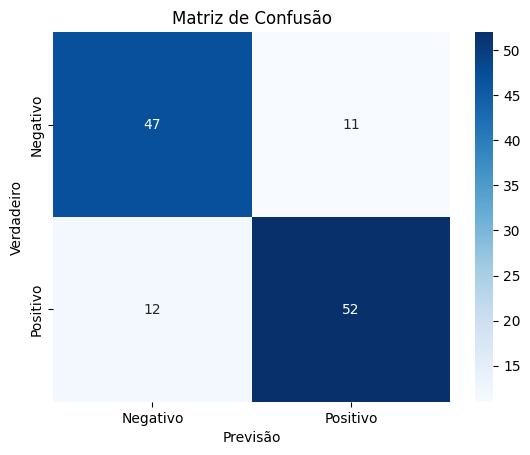

In [20]:
# Visualizar a Matriz de Confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Negativo', 'Positivo'],
            yticklabels = ['Negativo', 'Positivo'])
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()